In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
df=pd.read_csv("train (1).csv")
df.tail()

,1.126727,47.743884
64,-1.500082,414.076341
65,0.493507,-34.616994
66,1.725494,573.001536
67,0.872540,18.485251
68,0.725811,-16.120312


In [4]:
df.isnull().sum()

1.126727     0
47.743884    0
dtype: int64

no missing value

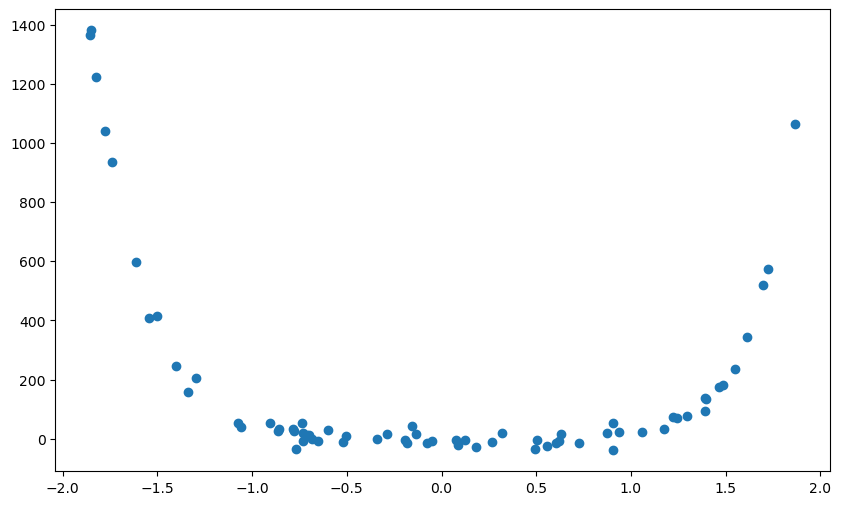

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])
plt.show()

From a general EDA, it looks like a even degree polynomial, but let us consider a general polynomial,
y=a1+a2x+a3x^2+a4x^3......

**Degree Analysis**
I'll start with degree=4 as less than that would be too simplistic.

In [ ]:

x=df.iloc[:, 0].values
y=df.iloc[:, 1].values
d=4 #degree of polynomial
while (d<=12):
    X=np.column_stack([x**i for i in range(0,d+1)])
    L=X.T @ X
    R=X.T @ y
    A=np.linalg.solve(L,R)
    y_pred=X @ A
    #Using Adjusted R2 Score to find the optimal degree of polynomial
    r2_score=1-(np.sum((y-y_pred)**2)/np.sum((y-np.mean(y))**2))
    adjusted_r2=1-(1-r2_score)*(len(y)-1)/(len(y)-X.shape[1]-1)
    print(f"Degree: {d}, Adjusted R2 Score: {adjusted_r2}")
    d+=1
X=np.column_stack([x**i for i in range(0,9)])
L=X.T @ X
R=X.T @ y
A=np.linalg.solve(L,R)

Degree: 4, Adjusted R2 Score: 0.9817611297689628
Degree: 5, Adjusted R2 Score: 0.9819873278040118
Degree: 6, Adjusted R2 Score: 0.9956375531852825
Degree: 7, Adjusted R2 Score: 0.9959332783750746
Degree: 8, Adjusted R2 Score: 0.9961618973505726
Degree: 9, Adjusted R2 Score: 0.9961142372098741
Degree: 10, Adjusted R2 Score: 0.9960573695650583
Degree: 11, Adjusted R2 Score: 0.996000751407845
Degree: 12, Adjusted R2 Score: 0.9959286812882976


Adjusted R2 is maximum at the best fitted curve. From this we can get that optimal degree is 8

In [7]:
print("Polynomial is:")
for i in range(len(A)):
    print(f"{A[i]}*x^{i}", end=" + " if i<len(A)-1 else "\n")

Polynomial is:
-4.19650705515131*x^0 + -29.75052186943816*x^1 + 1.4214634957259351*x^2 + 57.51729752583591*x^3 + 30.855419317104374*x^4 + -47.44420462378229*x^5 + -4.725962950475462*x^6 + 7.250946378930866*x^7 + 7.327818752219827*x^8


In [22]:
dt=pd.read_csv("test.csv")
dt.head()

,-1.819228,1255.525442
0,0.349282,18.559193
1,0.442694,-2.665981
2,0.044696,-3.456760
3,1.419504,131.568324
4,-0.577323,34.867037


Predicted values for test set:


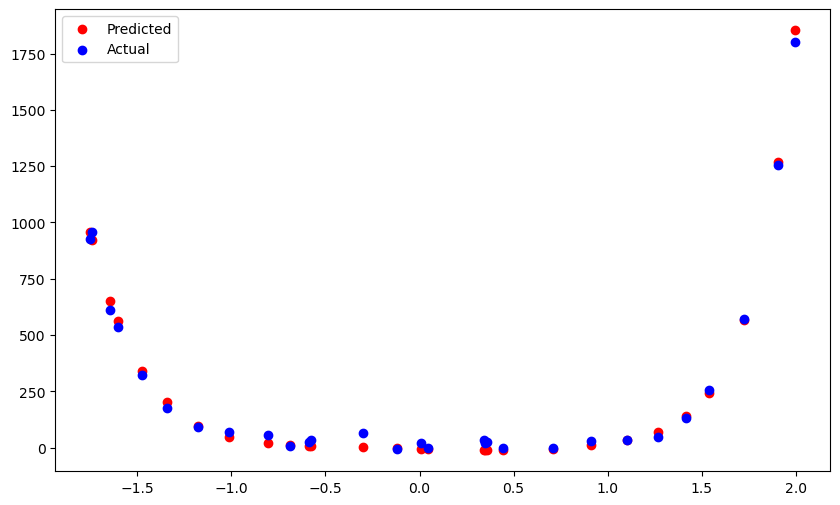

In [9]:
x_test=dt.iloc[:, 0].values
y_test=dt.iloc[:, 1].values
X_test=np.column_stack([x_test**i for i in range(0,9)])
y_test_pred=X_test @ A

print("Predicted values for test set:")
plt.figure(figsize=(10,6))
plt.scatter(x_test, y_test_pred, color='red', label='Predicted')
plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.legend()
plt.show()

In [10]:
r2_score=1-(np.sum((y_test-y_test_pred)**2)/np.sum((y_test-np.mean(y_test))**2))
print (f"R2 Score for test set: {r2_score}")
mse=np.mean((y_test-y_test_pred)**2)
print(f"Mean Squared Error for test set: {mse}")

R2 Score for test set: 0.9961881563239025
Mean Squared Error for test set: 733.1153884832422


In [11]:
indices = np.arange(len(df))
np.random.shuffle(indices)
train_idx, val_idx = indices[:int(0.8*len(df))], indices[int(0.8*len(df)):]
x_train, y_train = df.iloc[train_idx, 0].values, df.iloc[train_idx, 1].values
x_val, y_val = df.iloc[val_idx, 0].values, df.iloc[val_idx, 1].values

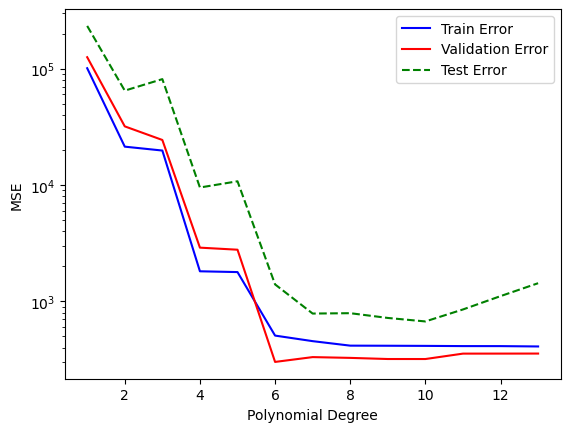

In [12]:
#Validation curves for polynomial degrees 1 to 14
degrees = range(1, 14)
train_errs, val_errs, test_errs = [], [], []

for d in degrees:
    X_train=np.column_stack([x_train**i for i in range(0, d+1)])
    X_val=np.column_stack([x_val**i for i in range(0, d+1)])
    A=np.linalg.pinv(X_train) @ y_train
    #Calculating MSE for train and validation sets
    train_errs.append(np.mean((X_train @ A - y_train)**2))
    val_errs.append(np.mean((X_val @ A - y_val)**2))
    X_test=np.column_stack([x_test**i for i in range(0, d+1)])
    test_err=np.mean((X_test @ A - y_test)**2)
    test_errs.append(test_err)


plt.plot(degrees, train_errs, label='Train Error', color='blue')
plt.plot(degrees, val_errs, label='Validation Error', color='red')
plt.plot(degrees, test_errs, label='Test Error', color='green', linestyle='--')
plt.yscale('log')
plt.xlabel('Polynomial Degree'), plt.ylabel('MSE'), plt.legend()
plt.show()

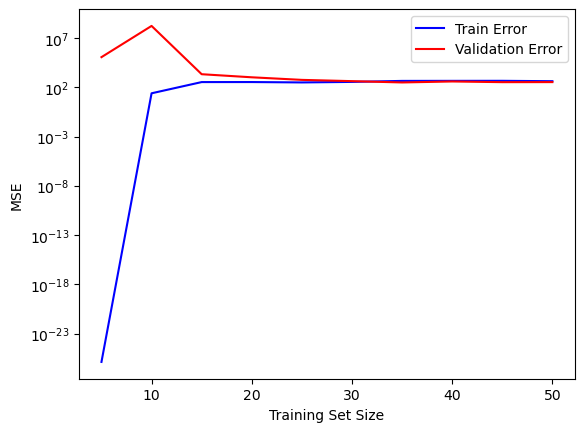

In [23]:
#Learning curves for polynomial degree 8, MSE vs training set size
d=8
m_sizes=range(5, len(x_train), 5)
train_errs = []
val_errs = []

for m in m_sizes:
    X_train_subset = np.column_stack([x_train[:m]**i for i in range(0, d+1)])
    X_val=np.column_stack([x_val**i for i in range(0, d+1)])
    A = np.linalg.pinv(X_train_subset) @ y_train[:m]
    train_err = np.mean((X_train_subset @ A - y_train[:m])**2)
    train_errs.append(train_err)
    val_err = np.mean((X_val @ A - y_val)**2)
    val_errs.append(val_err)

plt.plot(m_sizes, train_errs, label='Train Error', color='blue')
plt.plot(m_sizes, val_errs, label='Validation Error', color='red')
plt.yscale('log')
plt.xlabel('Training Set Size'), plt.ylabel('MSE'), plt.legend()
plt.show()
